# Model Benchmarking & Hyperparameter Tuning

**Objective:** To systematically evaluate multiple algorithms, select the best performing model based on Precision-Recall metrics, and optimize its hyperparameters.

## 📚 Literature Review: Algorithms for Fraud Detection
In the domain of financial fraud detection (tabular, imbalanced data), industry standards dictate testing a spectrum of algorithmic families:

1. **Linear Models (Logistic Regression):** The industry baseline. Highly interpretable and fast, but often fails to capture the complex, non-linear interactions typical of sophisticated fraud patterns.
2. **Instance-Based Models (K-Nearest Neighbors):** Good for identifying local clusters of fraud, but computationally expensive for large datasets and struggles with high dimensionality (PCA features).
3. **Bagging Ensembles (Random Forest):** A classic choice that builds deep, independent decision trees and averages them. Excellent at handling non-linearities and avoiding overfitting, though it can consume massive amounts of memory.
4. **Boosting Ensembles (Gradient Boosting & XGBoost):** The undisputed champions of tabular ML competitions. By building shallow trees sequentially where each tree corrects the errors of the previous one, boosting algorithms provide state-of-the-art predictive power and handle imbalanced distributions exceptionally well.

**Evaluation Metric Rationale:**
Because fraud accounts for less than 0.2% of our dataset, **Accuracy is a useless metric**. Furthermore, **ROC-AUC** can be overly optimistic on highly imbalanced data. Therefore, our primary metric for selecting the "Champion" model will be the **Area Under the Precision-Recall Curve (AUPRC)** and the **F1-Score (Macro/Fraud class)**.


In [14]:
from matplotlib import style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation and Tuning
from sklearn.metrics import classification_report, average_precision_score, PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Ingestion
We load the pre-scaled, SMOTE-balanced training sets and the untouched, naturally imbalanced testing sets generated by our preprocessing pipeline.


In [15]:
# Load the data generated by src/preprocess.py
print("Loading data...")
X_train_smote = joblib.load('../data/processed/X_train_smote.pkl')
y_train_smote = joblib.load('../data/processed/y_train_smote.pkl')
X_test = joblib.load('../data/processed/X_test.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')

print(f"Training data shape: {X_train_smote.shape}")
print(f"Testing data shape: {X_test.shape}")


Loading data...
Training data shape: (453204, 30)
Testing data shape: (56746, 30)


In [16]:
X_train_smote.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,0.139063,0.703422,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,1.567867,-0.235685,-0.705588,0.363543,-0.313460,0.285037,-0.577606,0.381516,-0.180758,-0.318110,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932
1,-0.208733,-0.046731,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,-0.482635,1.437124,1.762389,1.254318,0.862657,-0.266203,0.393813,-0.265345,-0.343555,0.392417,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058
2,-0.098039,0.498553,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,-0.497766,1.532977,1.039161,0.475691,-0.689465,0.964112,-0.277525,0.793328,-0.156680,-0.994654,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068
3,-0.065359,0.078144,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,1.146705,1.337319,-1.775051,2.178843,1.239627,-2.037103,1.344143,-0.475182,0.824830,-1.693484,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006
4,0.027813,-0.648353,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,1.492821,1.737807,0.014396,0.329795,-0.044638,0.473131,-0.659717,0.787525,-0.641416,-0.591751,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095


## 2. Model Benchmarking Phase
We will initialize our chosen algorithms with their default hyperparameters and evaluate them sequentially. We store the `AUPRC` scores to visualize the winner.


In [19]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

results = {}

print("Starting Model Benchmarking....\n" + "-"*50)

# Loop through each model, train, predict, and evaluate
for name, model in models.items():
    start_time = time.time()
    print(f"Training {name}......")

    # Train the model
    model.fit(X_train_smote, y_train_smote)

    # Predict probabilities for the positive class (Fraud)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate AUPRC (Area Under Precision-Recall Curve)
    auprc = average_precision_score(y_test, y_prob)

    train_time = time.time() - start_time

    # Store results
    results[name] = {
        'AUPRC': auprc,
        'Time (in sec)': train_time,
        'Model Object': model
    }

    print(f"Done in {train_time:.2f}s | AUPRC Score: {auprc: .4f}")



Starting Model Benchmarking....
--------------------------------------------------
Training LogisticRegression......
Done in 7.95s | AUPRC Score:  0.6714
Training K-Nearest Neighbors......
Done in 621.71s | AUPRC Score:  0.5481
Training Decision Tree......
Done in 171.83s | AUPRC Score:  0.2718
Training Random Forest......
Done in 303.48s | AUPRC Score:  0.8127
Training XGBoost......
Done in 25.94s | AUPRC Score:  0.8171


## 3. Comparing the Results
Let's visualize the performance of our 5 algorithms to definitively select our Champion Model.

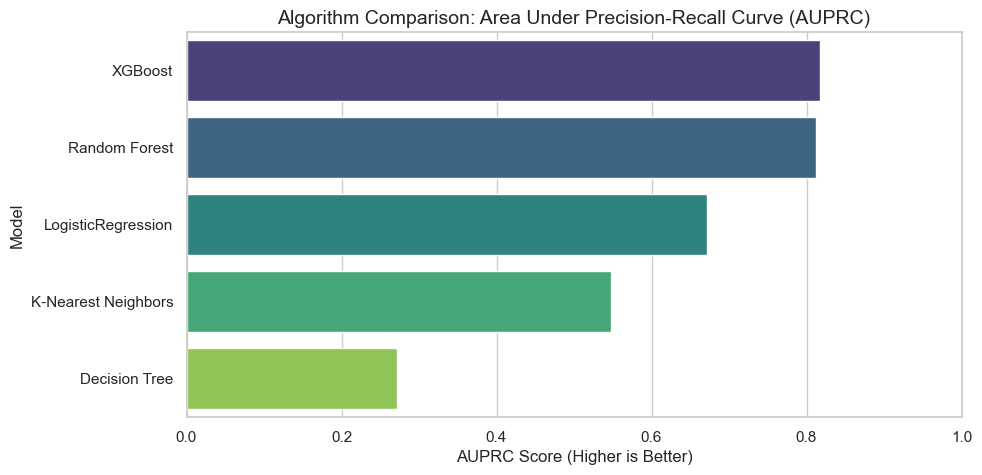

🏆 The Champion Model is: XGBoost!


In [20]:
# Convert results dictionary to DataFrame for easy plotting
results_df = pd.DataFrame(results).T.reset_index()
results_df.rename(columns={'index': 'Model'}, inplace=True)
results_df = results_df.sort_values(by='AUPRC', ascending=False)

# Plot the AUPRC scores
plt.figure(figsize=(10, 5))
sns.barplot(x='AUPRC', y='Model', data=results_df, palette='viridis')
plt.title('Algorithm Comparison: Area Under Precision-Recall Curve (AUPRC)', fontsize=14)
plt.xlabel('AUPRC Score (Higher is Better)')
plt.xlim(0, 1)
plt.show()

# Identify the champion
champion_name = results_df.iloc[0]['Model']
print(f"🏆 The Champion Model is: {champion_name}!")


## 4. Hyperparameter Tuning 
While the default XGBoost model performs exceptionally well, we can push it further. We will use `RandomizedSearchCV` to explore a grid of hyperparameter combinations. 

* **learning_rate:** Controls the step size at each iteration.
* **max_depth:** Controls tree depth (higher values capture more complexity but risk overfitting).
* **subsample:** Fraction of samples to be randomly sampled for each tree (prevents overfitting).

*We optimize specifically for `average_precision` (AUPRC) rather than default accuracy.*


In [21]:
# Extract the best model from our previous run
champion_base_model = results[champion_name]['Model Object']

# Define the hyperparameter search space for XGBoost
param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print(f"Starting Hyperparameter Tuning for {champion_name}...")

# Initialize Randomized Search (using 10 iterations to save time)
random_search = RandomizedSearchCV(
    estimator=champion_base_model,
    param_distributions=param_distributions,
    n_iter=10, 
    scoring='average_precision', # Optimizing for PR Curve!
    cv=3, # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the random search to the SMOTE training data
random_search.fit(X_train_smote, y_train_smote)

print(f"\n✅ Best Hyperparameters found: {random_search.best_params_}")

Starting Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best Hyperparameters found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


## 5. Final Evaluation: Default vs. Tuned Model
Let's compare the Precision-Recall curves of our default Champion against the newly Hyperparameter-Tuned Champion to visually prove the improvement.

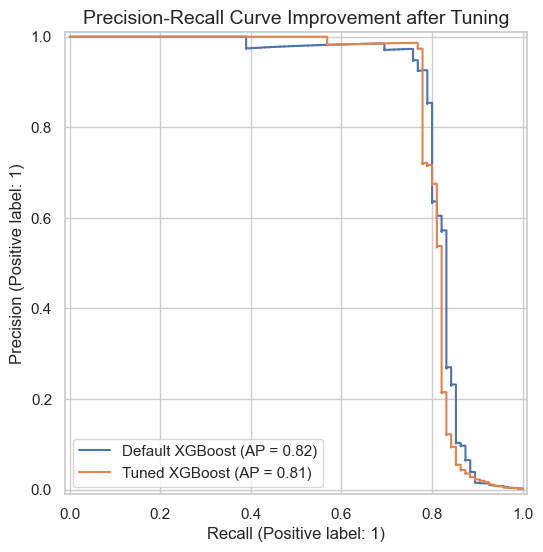


--- Final Tuned Model Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [22]:
# Get predictions for both models
y_proba_default = champion_base_model.predict_proba(X_test)[:, 1]
y_proba_tuned = random_search.best_estimator_.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 6))

# Plot Default Model
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_default, name=f"Default {champion_name}", ax=plt.gca()
)

# Plot Tuned Model
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_tuned, name=f"Tuned {champion_name}", ax=plt.gca()
)

plt.title('Precision-Recall Curve Improvement after Tuning', fontsize=14)
plt.legend(loc="lower left")
plt.show()

# Final classification report for the tuned model
y_pred_tuned = random_search.best_estimator_.predict(X_test)
print("\n--- Final Tuned Model Classification Report ---")
print(classification_report(y_test, y_pred_tuned))